In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
hours = np.arange(1, 21)

scores = hours * 4.5 + np.random.randint(-3, 4, size=20)

df = pd.DataFrame({
    "Hours_Studied": hours,
    "Exam_Score": scores
})

print(df.head())
print("\nShape:", df.shape)

   Hours_Studied  Exam_Score
0              1         7.5
1              2         9.0
2              3        14.5
3              4        21.0
4              5        21.5

Shape: (20, 2)


In [3]:
X = df[['Hours_Studied']].values
y = df[['Exam_Score']].values

print(X.shape)
print(y.shape)

(20, 1)
(20, 1)


In [4]:
W1 = np.random.randn(1,4)
b1 = np.zeros((1,4))

W2 = np.random.randn(4,1)
b2 = np.zeros((1,1))

print("W1:",W1.shape)
print("b1:",b1.shape)
print("W2:",W2.shape)
print("b2:",b2.shape)

W1: (1, 4)
b1: (1, 4)
W2: (4, 1)
b2: (1, 1)


In [5]:
def relu(x):
    return np.maximum(0,x)

test=np.array([-3,-1,0,2,5])

print(relu(test))

[0 0 0 2 5]


In [6]:
def linear(x):
    return x

print(linear(np.array([5,-2,10])))

[ 5 -2 10]


In [7]:
def forward(X):

    global Z1,A1,Z2,A2

    Z1 = np.dot(X,W1)+b1
    A1 = relu(Z1)

    Z2 = np.dot(A1,W2)+b2
    A2 = linear(Z2)

    return A2

prediction=forward(X[:4])

print(prediction)

[[0.004935]
 [0.00987 ]
 [0.014805]
 [0.01974 ]]


In [8]:
# Task 6: Mean Squared Error (MSE) Loss
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

prediction = forward(X[:4])

loss = mse_loss(y[:4], prediction)

print("Loss:", loss)

Loss: 196.7476552449785


In [9]:
# Task 7: Backpropagation
def relu_derivative(x):
    return (x > 0).astype(float)

def backprop(X_batch, y_batch):

    global W1, b1, W2, b2
    global Z1, A1, Z2, A2

    m = X_batch.shape[0]

    # Output layer gradients
    dZ2 = (2/m) * (A2 - y_batch)
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # Hidden layer gradients
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = np.dot(X_batch.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

In [10]:
# Check Gradient Shapes
dW1, db1, dW2, db2 = backprop(X[:4], y[:4])

print("dW1:", dW1.shape)
print("db1:", db1.shape)
print("dW2:", dW2.shape)
print("db2:", db2.shape)

dW1: (1, 4)
db1: (1, 4)
dW2: (4, 1)
db2: (1, 1)


In [11]:
# Task 8: Gradient Descent Optimizer
learning_rate = 0.001

def update_params(dW1, db1, dW2, db2):

    global W1, b1, W2, b2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

In [12]:
# Test One Update Step
prediction = forward(X[:4])

loss_before = mse_loss(y[:4], prediction)

dW1, db1, dW2, db2 = backprop(X[:4], y[:4])

update_params(dW1, db1, dW2, db2)

prediction = forward(X[:4])

loss_after = mse_loss(y[:4], prediction)

print("Loss Before:", loss_before)
print("Loss After :", loss_after)

Loss Before: 196.7476552449785
Loss After : 195.74762725835672


In [13]:
# Task 9: Create Batches
def create_batches(X, y, batch_size):

    batches = []

    for i in range(0, len(X), batch_size):
        X_batch = X[i:i+batch_size]
        y_batch = y[i:i+batch_size]
        batches.append((X_batch, y_batch))

    return batches

batches = create_batches(X, y, 4)

print("Number of batches:", len(batches))

Number of batches: 5


In [14]:
# Task 10 & 11: Full Training Loop
epochs = 100
batch_size = 4

loss_history = []

for epoch in range(epochs):

    batches = create_batches(X, y, batch_size)

    epoch_loss = 0

    for X_batch, y_batch in batches:

        prediction = forward(X_batch)

        loss = mse_loss(y_batch, prediction)

        dW1, db1, dW2, db2 = backprop(X_batch, y_batch)

        update_params(dW1, db1, dW2, db2)

        epoch_loss += loss

    avg_loss = epoch_loss / len(batches)

    loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}, Loss = {avg_loss:.4f}")

Epoch 1, Loss = 2165.9719
Epoch 10, Loss = 892.7647
Epoch 20, Loss = 1055.2405
Epoch 30, Loss = 406.9149
Epoch 40, Loss = 2508.0852
Epoch 50, Loss = 2170.2338
Epoch 60, Loss = 1893.7297
Epoch 70, Loss = 1667.4379
Epoch 80, Loss = 1482.2438
Epoch 90, Loss = 1330.6871
Epoch 100, Loss = 1206.6612


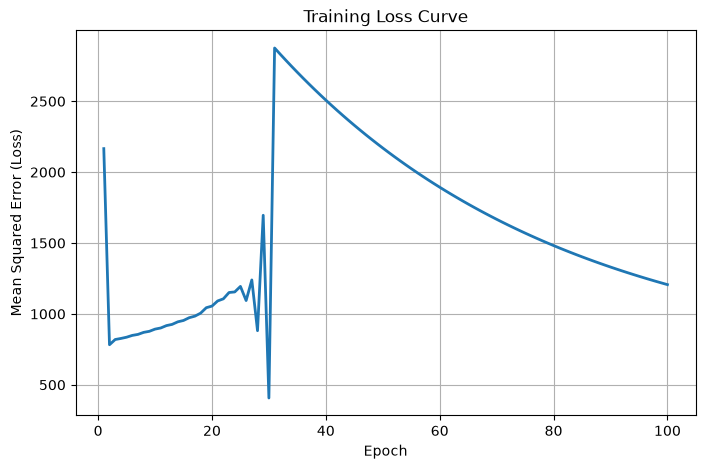

In [15]:
# Task 12: Plot the Loss Curve
plt.figure(figsize=(8,5))

plt.plot(range(1, epochs + 1), loss_history, linewidth=2)

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (Loss)")
plt.grid(True)

plt.show()

In [16]:
# Task 13: Test the Trained Model
test_hours = np.array([[3],
                       [11],
                       [18]])

predictions = forward(test_hours)

print("Hours Studied\tPredicted Score")

for h, p in zip(test_hours, predictions):
    print(f"{h[0]}\t\t{p[0]:.2f}")

Hours Studied	Predicted Score
3		24.27
11		24.27
18		24.27


In [17]:
learning_rate = 0.01

In [18]:
learning_rate = 0.001

In [20]:
# Compare Learning Rates
def train_model(learning_rate):

    global W1, b1, W2, b2

    # Initialize parameters again
    W1 = np.random.randn(1,4)
    b1 = np.zeros((1,4))

    W2 = np.random.randn(4,1)
    b2 = np.zeros((1,1))

    losses = []

    for epoch in range(100):

        batches = create_batches(X, y, 4)

        epoch_loss = 0

        for X_batch, y_batch in batches:

            prediction = forward(X_batch)

            loss = mse_loss(y_batch, prediction)

            dW1, db1, dW2, db2 = backprop(X_batch, y_batch)

            # Update weights
            W1 -= learning_rate * dW1
            b1 -= learning_rate * db1

            W2 -= learning_rate * dW2
            b2 -= learning_rate * db2

            epoch_loss += loss

        losses.append(epoch_loss / len(batches))

    return losses

In [21]:
loss_lr_01 = train_model(0.01)

loss_lr_001 = train_model(0.001)

loss_lr_0001 = train_model(0.0001)

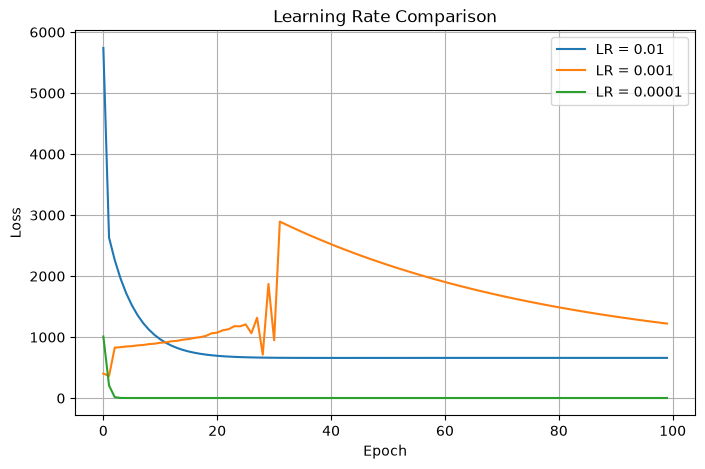

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(loss_lr_01, label="LR = 0.01")
plt.plot(loss_lr_001, label="LR = 0.001")
plt.plot(loss_lr_0001, label="LR = 0.0001")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison")

plt.legend()
plt.grid(True)

plt.show()